In [3]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# DIRECTORY CONFIGURATION
# ============================================================

ROOT = Path.cwd()

TRAINING_DATA_DIR = ROOT / "Data" / "training_data"

OUTPUT_DIR = ROOT / "Results" / "training_curves"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current directory:", ROOT)
print("Training data directory:", TRAINING_DATA_DIR)
print("Output directory:", OUTPUT_DIR)


NODE_CONFIGS = {
    4: {
        "pnn_path": TRAINING_DATA_DIR / "4_PNN_model.json",
        "fnn_path": TRAINING_DATA_DIR / "4_FNN_model.json",
        "xticks": [0, 2000, 4000, 6000],
        "ylim": (1e-6, 1e0),
        "pnn_val_markers": 10,
        "fnn_val_markers": 10,
    },
    6: {
        "pnn_path": TRAINING_DATA_DIR / "6_PNN_model.json",
        "fnn_path": TRAINING_DATA_DIR / "6_FNN_model.json",
        "xticks": [0, 4000, 8000, 12000],
        "ylim": (1e-4, 1e0),
        "pnn_val_markers": 10,
        "fnn_val_markers": 10,
    },
    8: {
        "pnn_path": TRAINING_DATA_DIR / "8_PNN_model.json",
        "fnn_path": TRAINING_DATA_DIR / "8_FNN_model.json",
        "xticks": [0, 1000, 2000, 3000],
        "ylim": (1e-3, 1e0),
        "pnn_val_markers": 10,
        "fnn_val_markers": 4,
    },
}


# ============================================================
# GLOBAL SETTINGS
# ============================================================

SAVE_DPI = 600


# ============================================================
# MATPLOTLIB STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],

    "axes.labelsize": 30,
    "axes.titlesize": 24,
    "xtick.labelsize": 23,
    "ytick.labelsize": 23,
    "legend.fontsize": 22,

    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,

    "figure.dpi": 600,
    "savefig.dpi": SAVE_DPI,

    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


# ============================================================
# DATA HELPERS
# ============================================================

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def get_array_from_possible_keys(data, possible_keys):
    for key in possible_keys:
        if key in data:
            return np.asarray(data[key], dtype=float)

    raise KeyError(
        "Could not find the required loss key.\n"
        f"Tried keys: {possible_keys}\n"
        f"Available keys: {list(data.keys())}"
    )


def extract_train_val_losses(json_path):
    data = load_json(json_path)

    train_keys = [
        "train_loss",
        "training_loss",
        "train_losses",
        "training_losses",
        "loss_train",
        "losses_train",
        "history_train_loss",
    ]

    val_keys = [
        "val_loss",
        "validation_loss",
        "val_losses",
        "validation_losses",
        "loss_val",
        "losses_val",
        "history_val_loss",
    ]

    train_loss = get_array_from_possible_keys(data, train_keys)
    val_loss = get_array_from_possible_keys(data, val_keys)

    return train_loss, val_loss


def make_epochs(loss_array):
    return np.arange(1, len(loss_array) + 1)


Current directory: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code
Training data directory: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Data/training_data
Output directory: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves


## Code To plot the training curves



Plotting simple training curve for n = 4 (legend=10, label=14)
Saved PNG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n4_legend10_label14.png
Saved PDF: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n4_legend10_label14.pdf
Saved SVG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n4_legend10_label14.svg


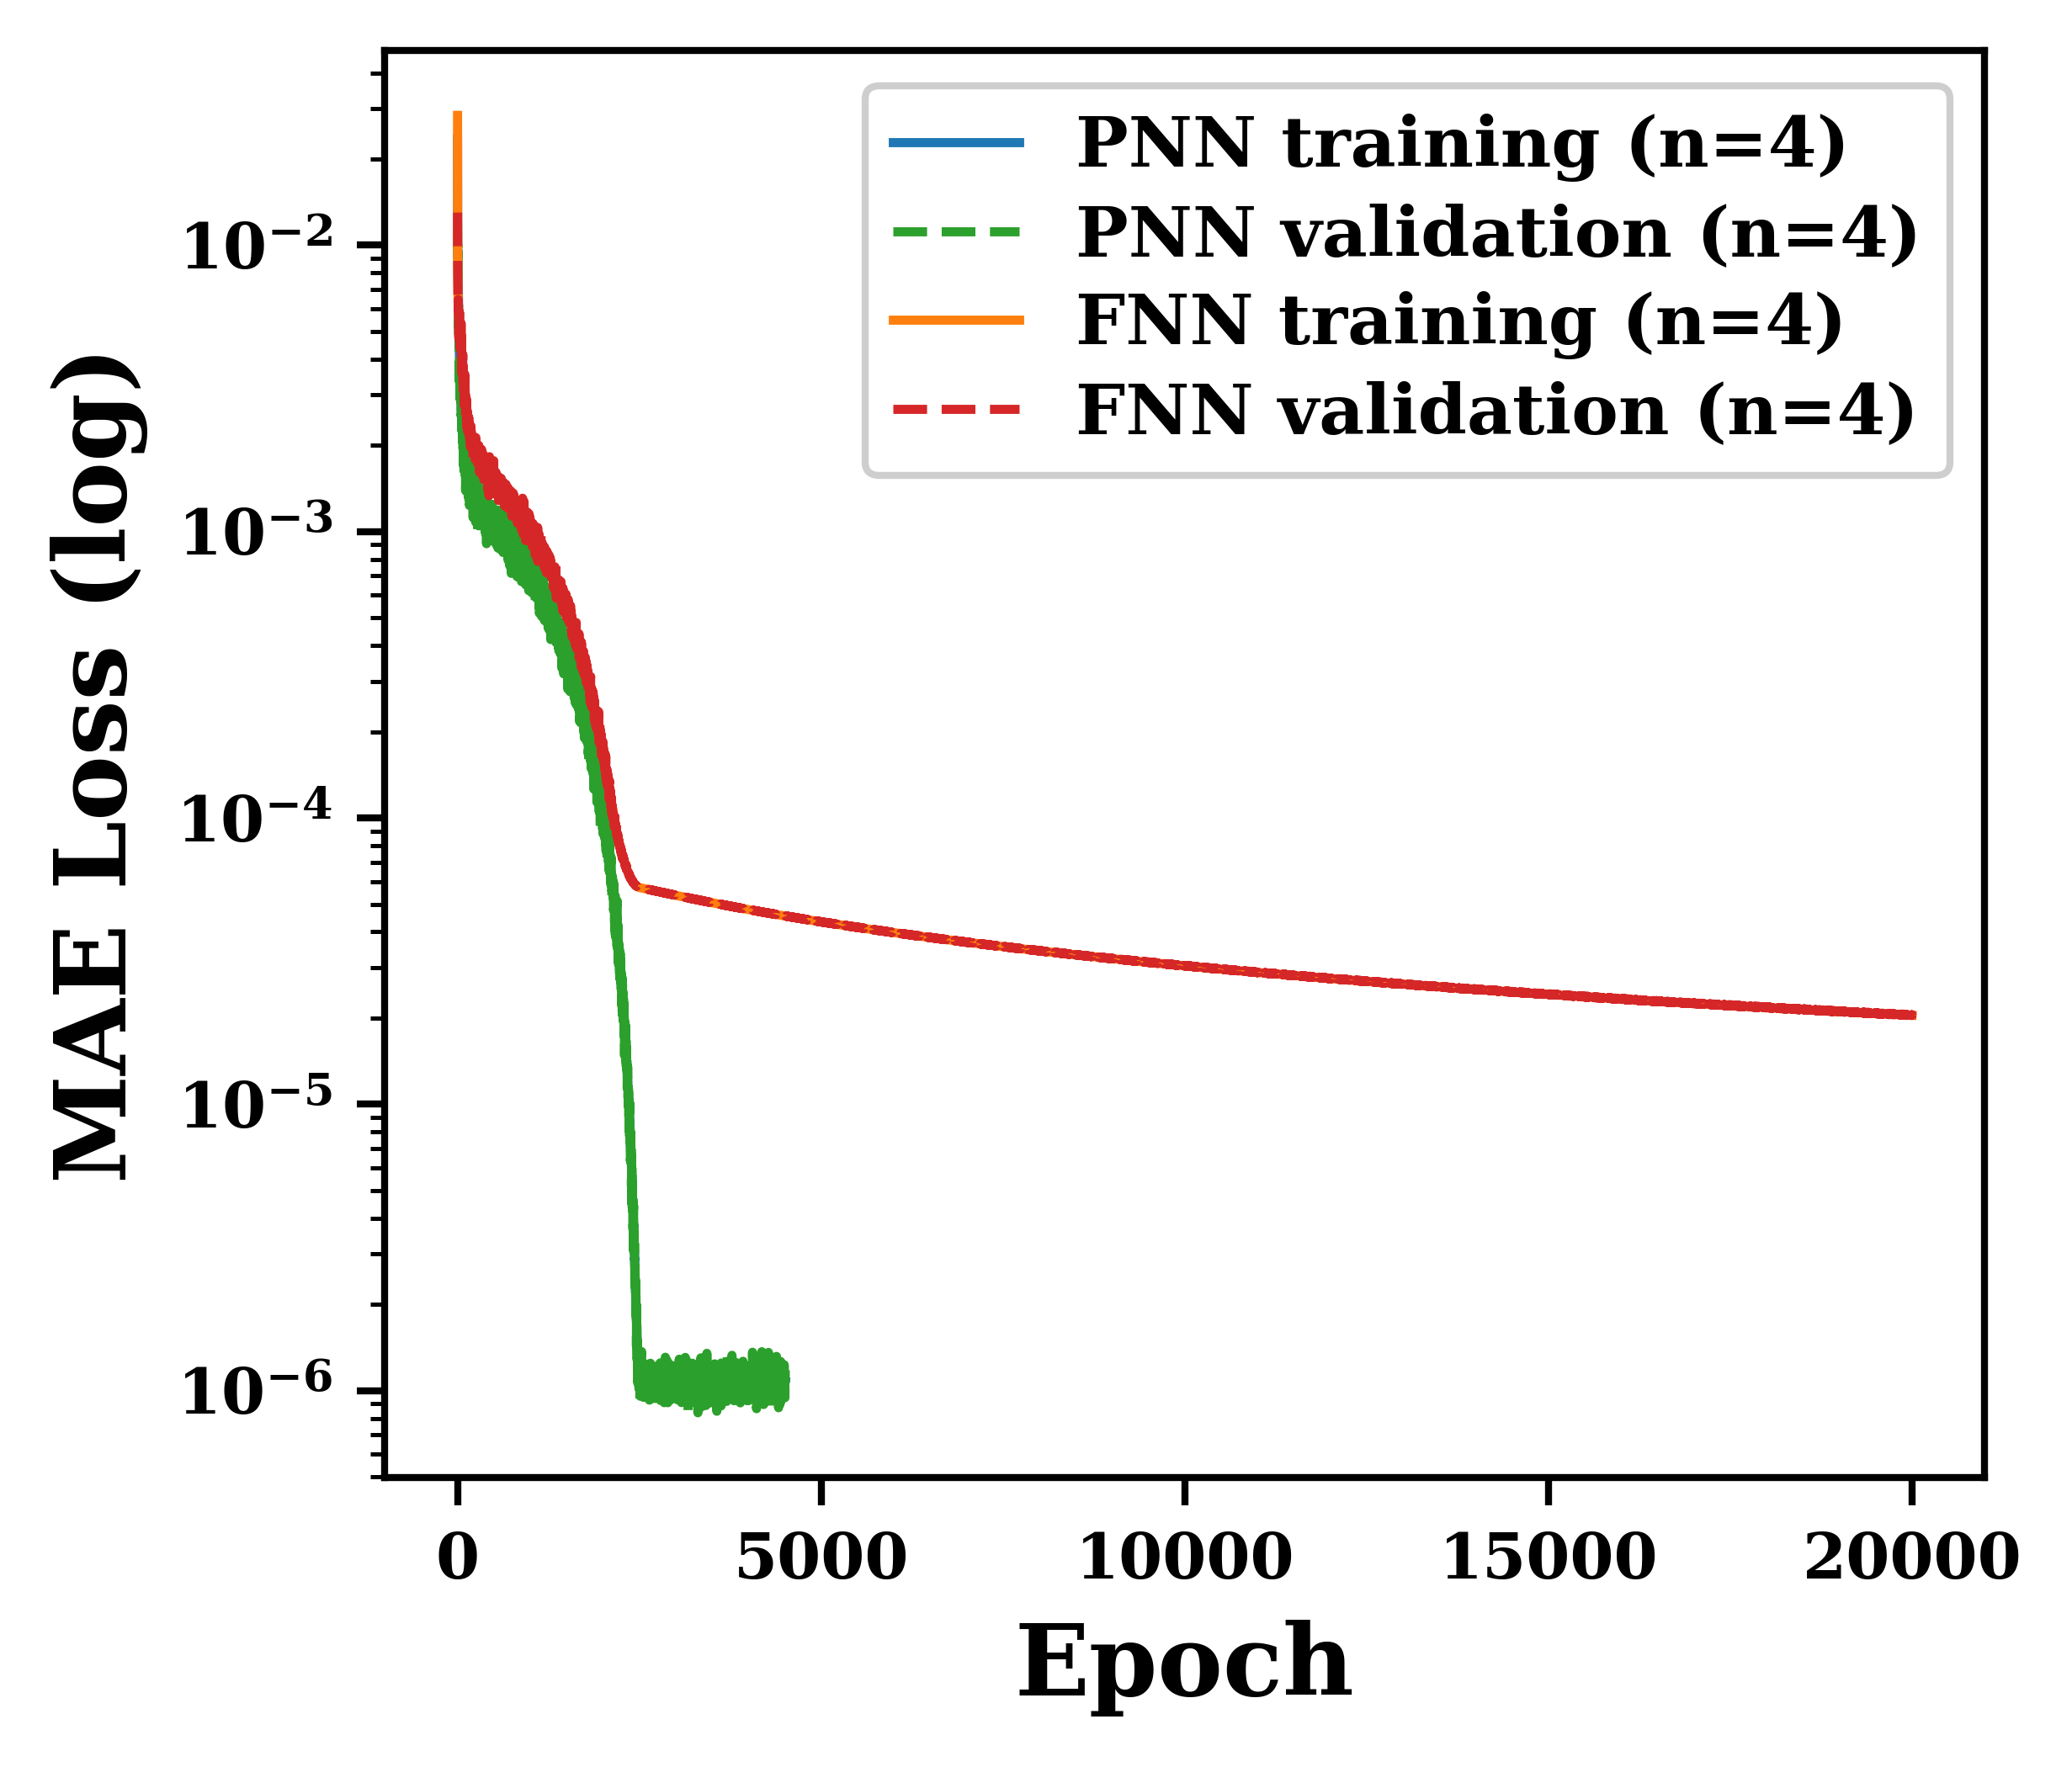


Plotting simple training curve for n = 6 (legend=10, label=14)
Saved PNG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n6_legend10_label14.png
Saved PDF: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n6_legend10_label14.pdf
Saved SVG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n6_legend10_label14.svg


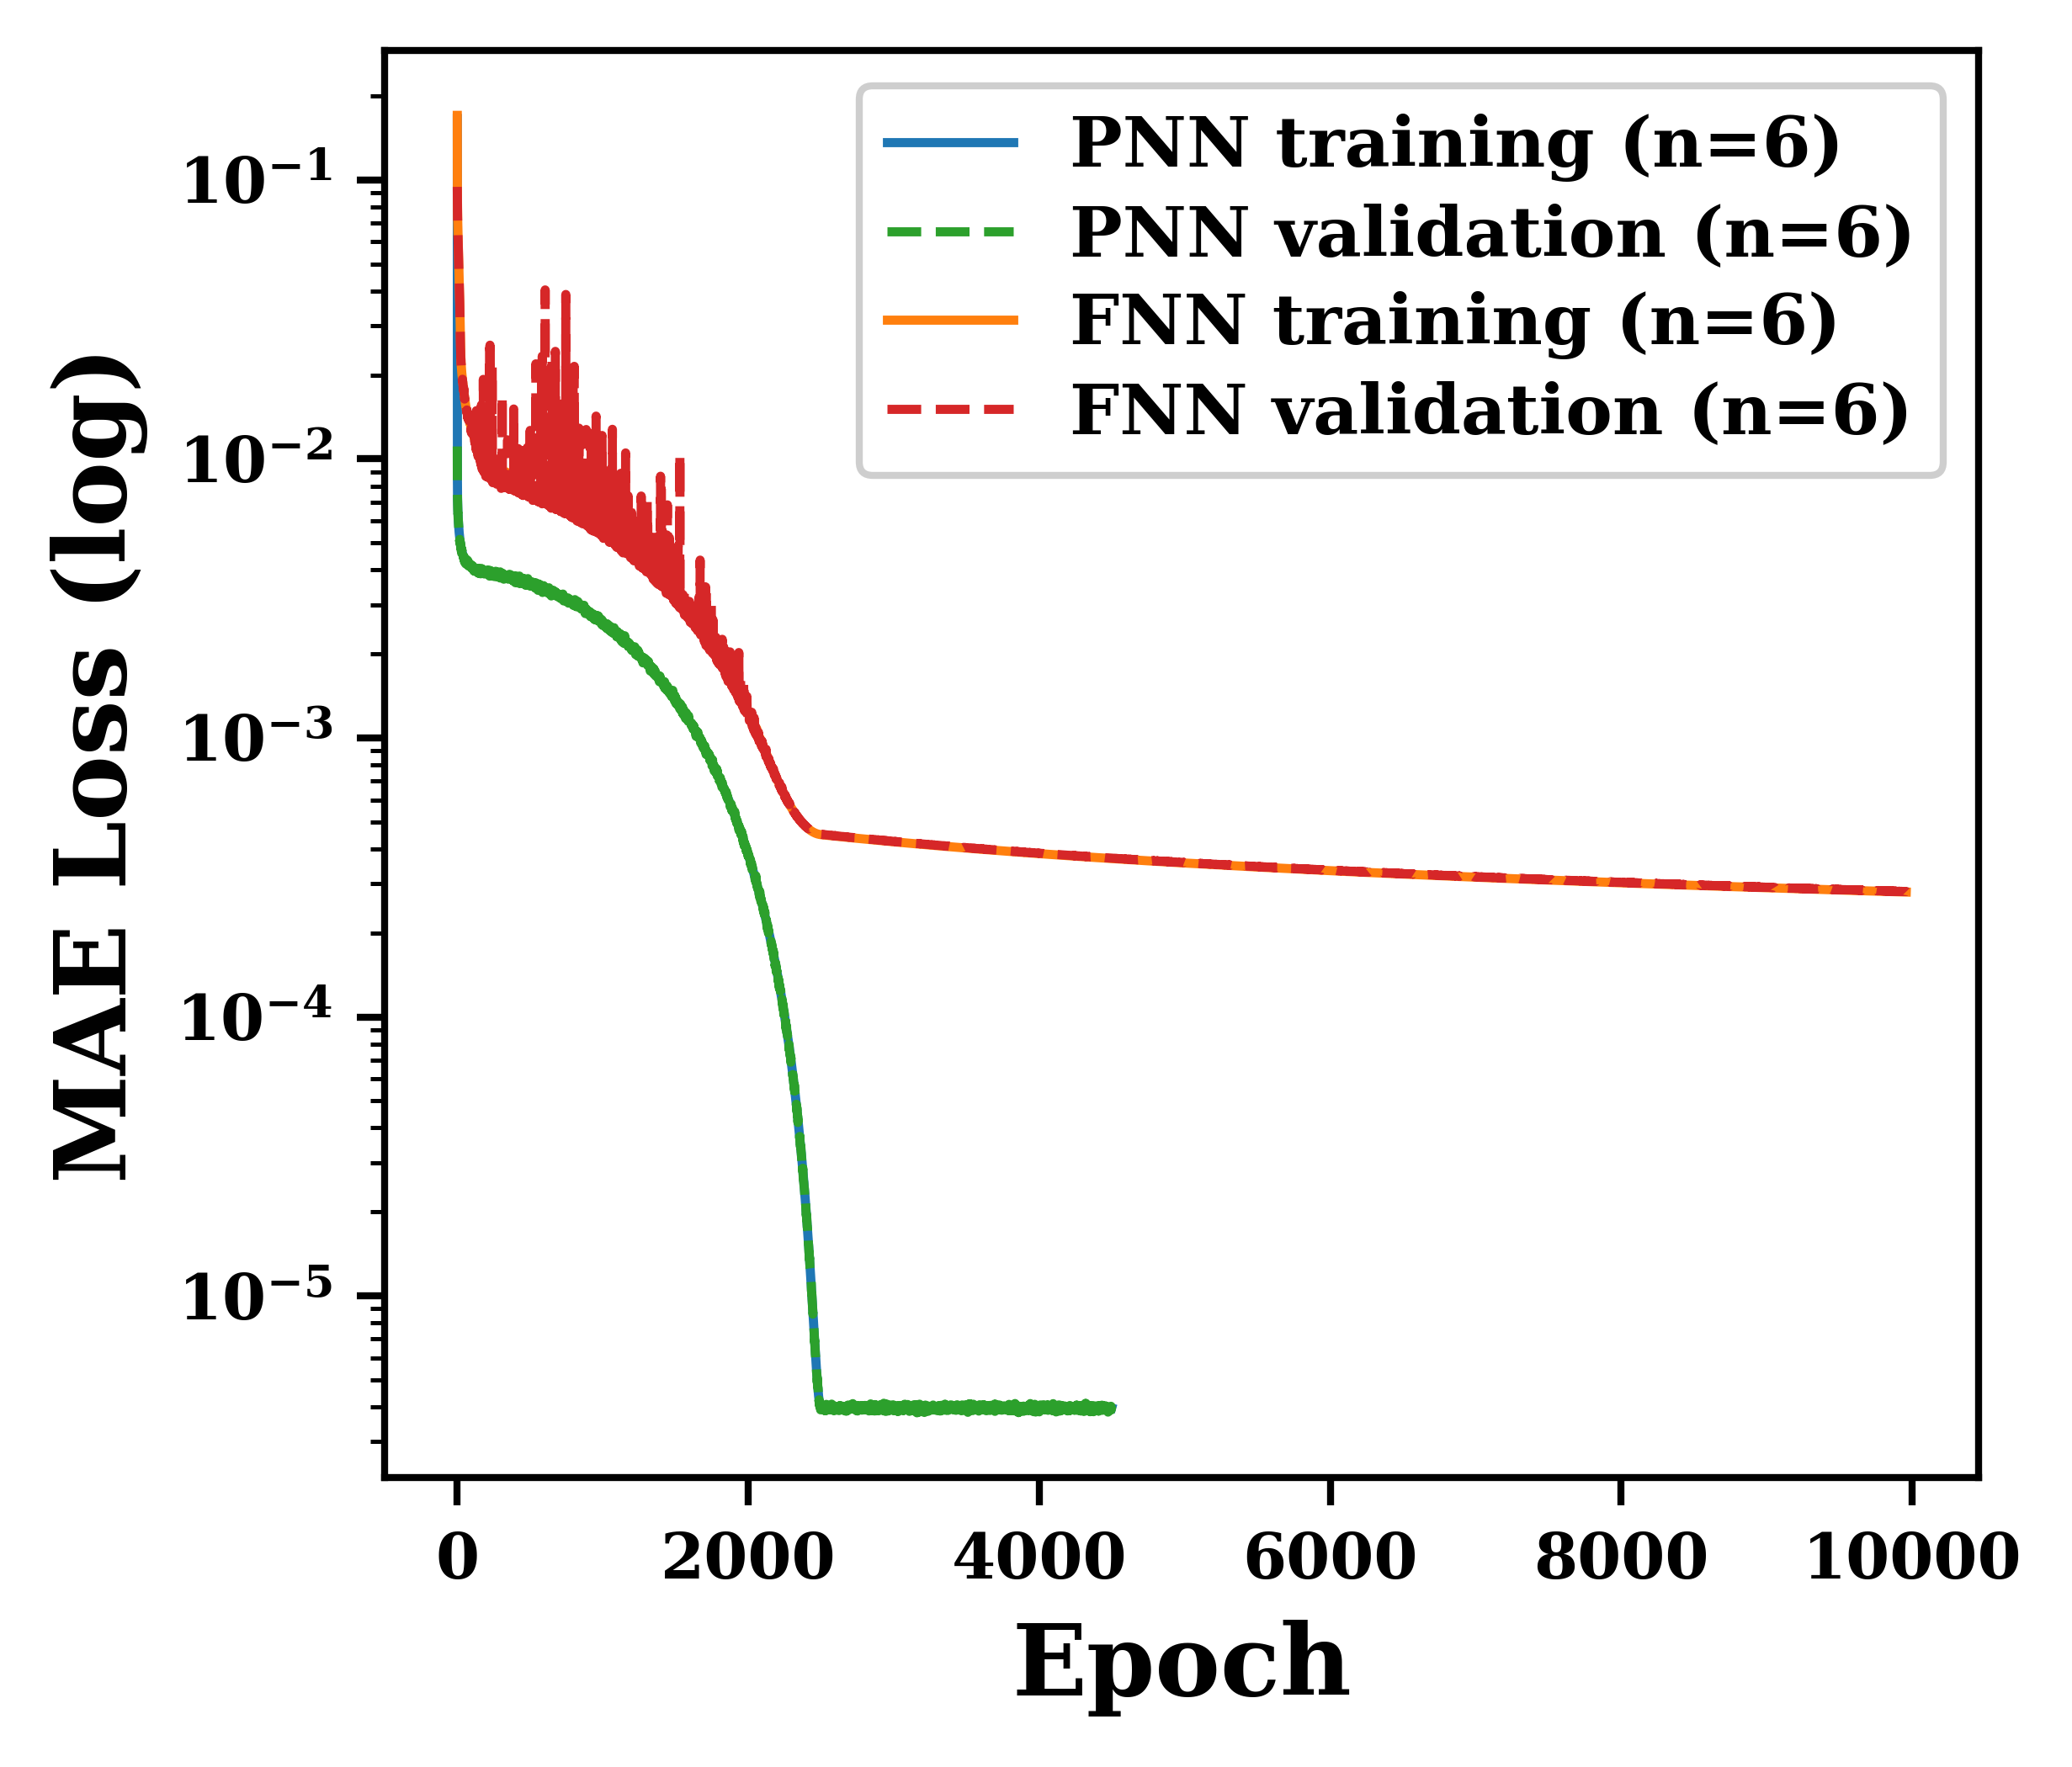


Plotting simple training curve for n = 8 (legend=10, label=14)
Saved PNG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n8_legend10_label14.png
Saved PDF: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n8_legend10_label14.pdf
Saved SVG: /home/bo48god/projects/deep_dreaming/PolySurrogate_temp/plotting_code/Results/training_curves/training_curve_simple_n8_legend10_label14.svg


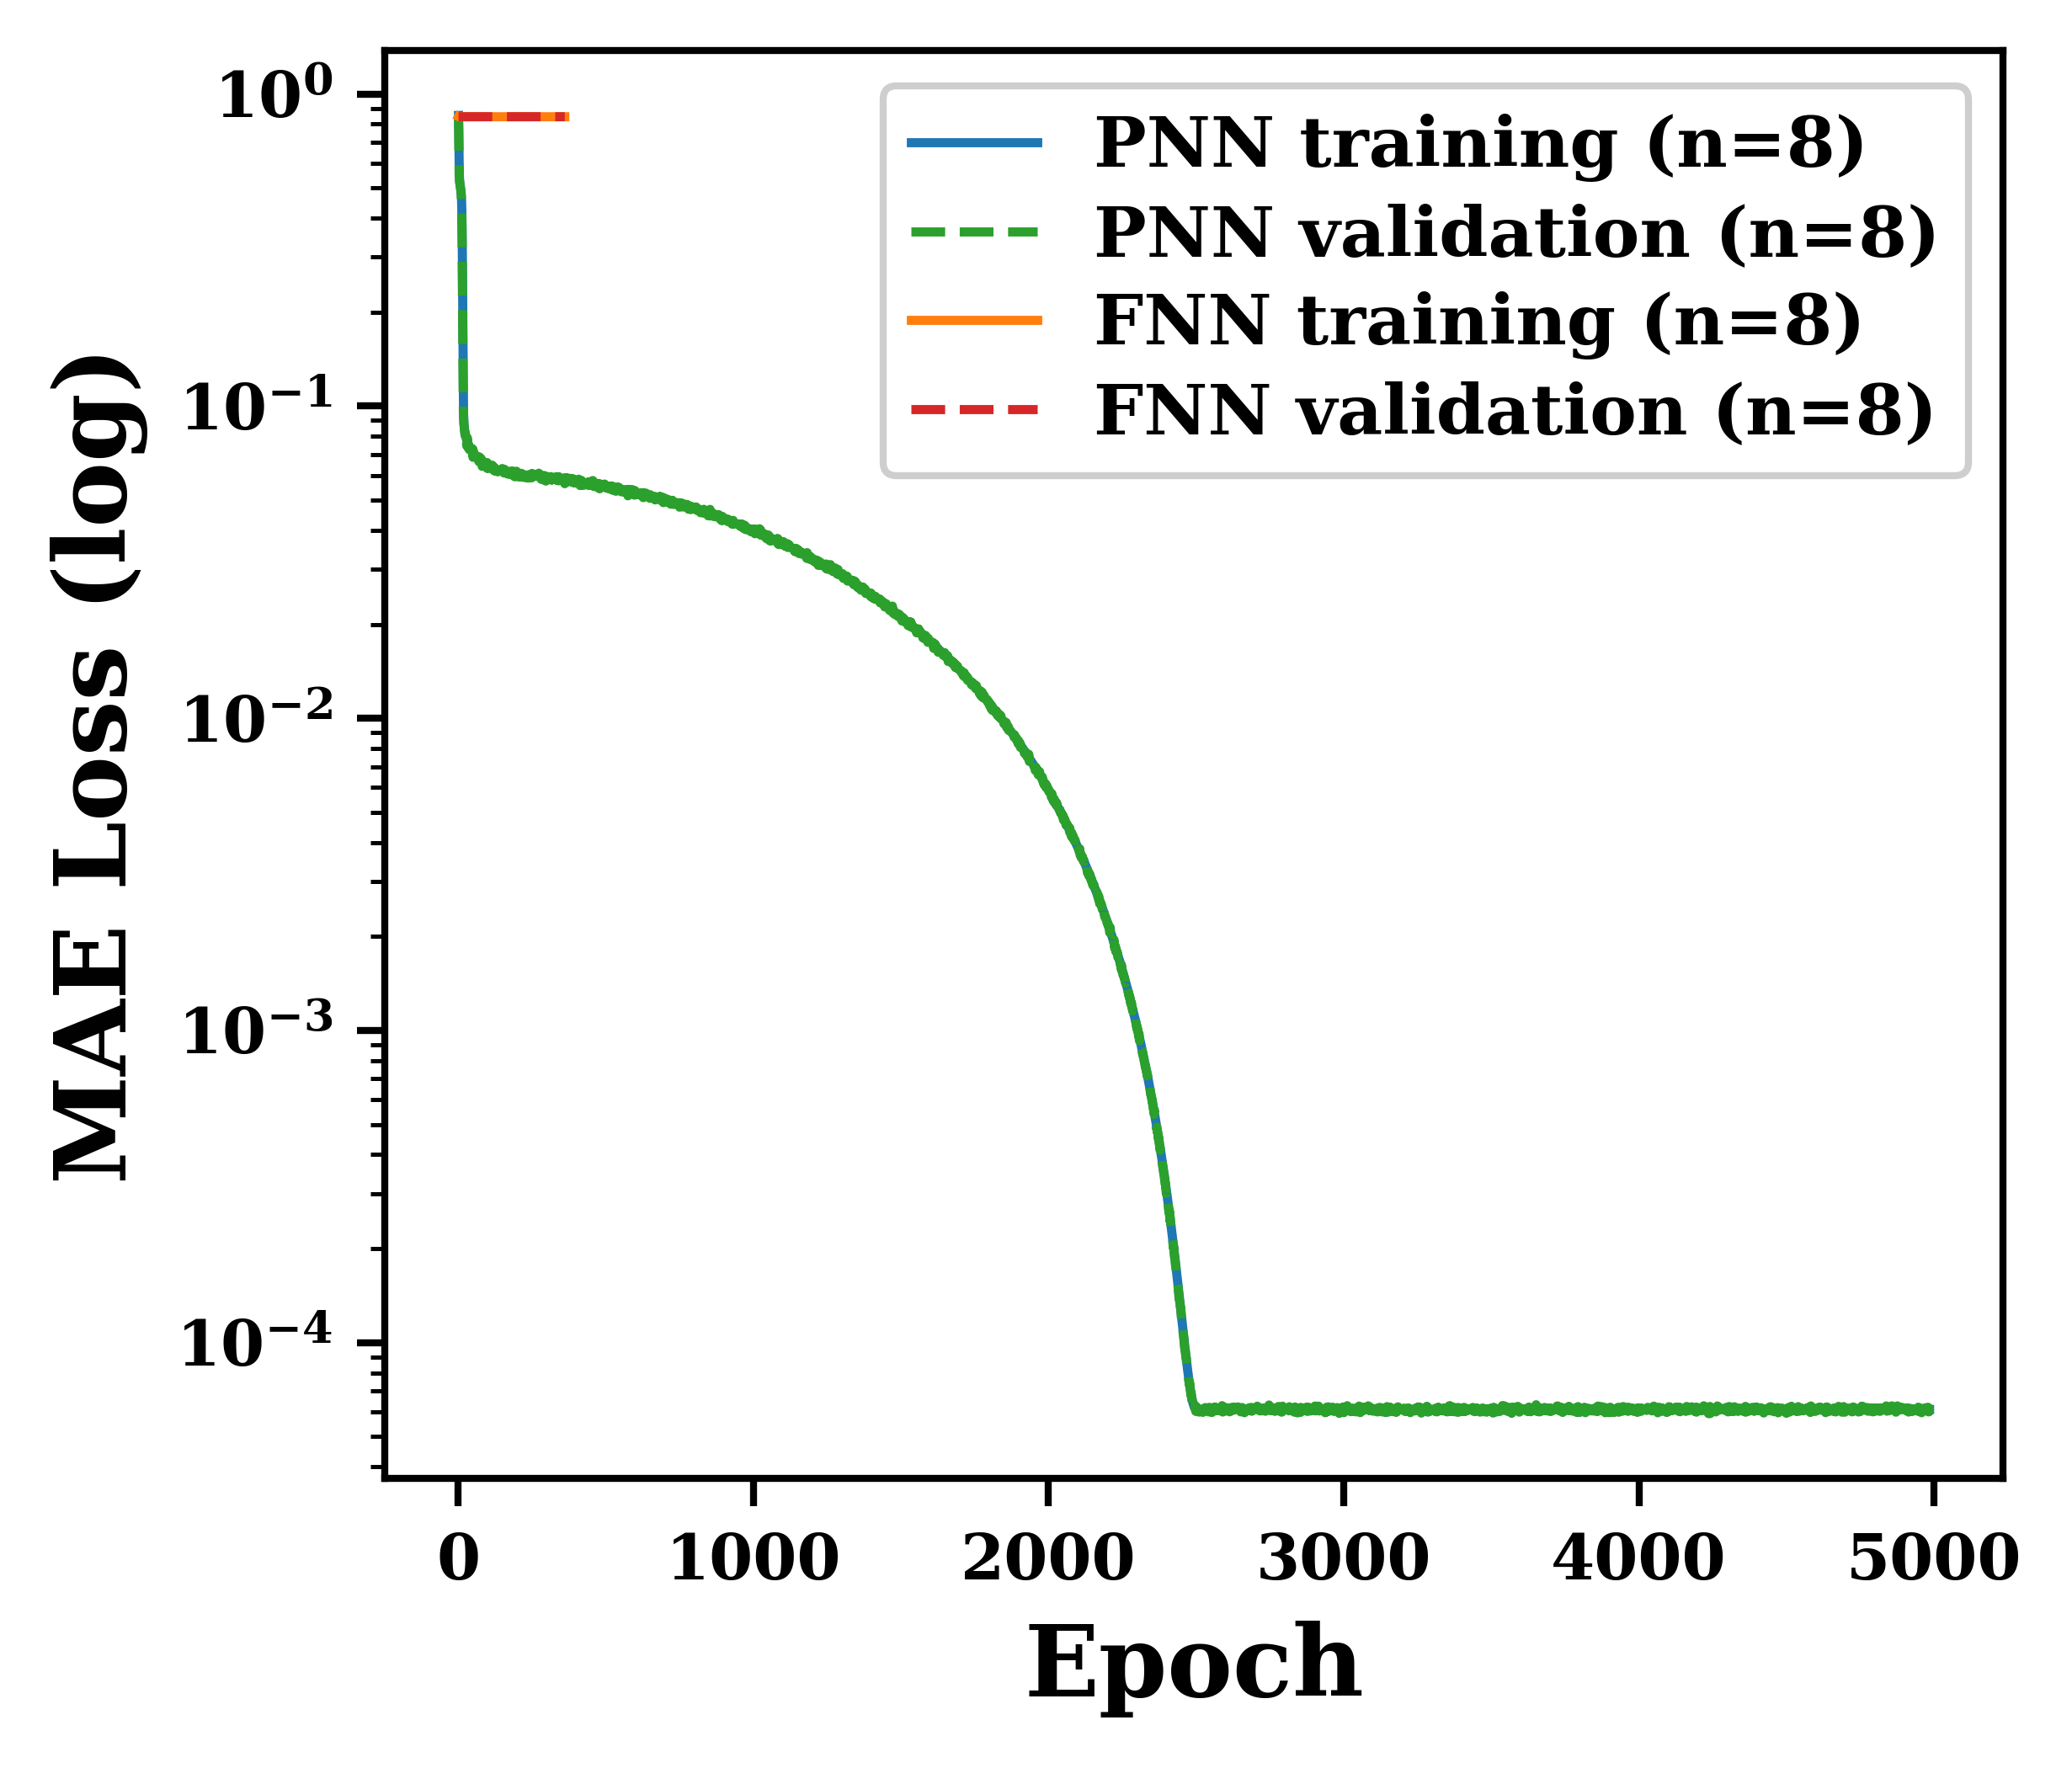


All 3 simple training-curve figures generated (paper variant: legend10_label14).


In [4]:
SIMPLE_COLORS = {
    "pnn_train": "tab:blue",
    "pnn_val": "tab:green",
    "fnn_train": "tab:orange",
    "fnn_val": "tab:red",
}


def plot_single_node_simple(n, cfg, legend_fontsize=9, label_fontsize=11, suffix=""):
    pnn_train, pnn_val = extract_train_val_losses(cfg["pnn_path"])
    fnn_train, fnn_val = extract_train_val_losses(cfg["fnn_path"])

    pnn_epochs = make_epochs(pnn_train)
    fnn_epochs = make_epochs(fnn_train)

    fig, ax = plt.subplots(figsize=(4.2, 3.6))

    ax.plot(pnn_epochs, pnn_train, color=SIMPLE_COLORS["pnn_train"], linestyle="-",
            linewidth=1.3, label=f"PNN training (n={n})")
    ax.plot(pnn_epochs, pnn_val, color=SIMPLE_COLORS["pnn_val"], linestyle="--",
            linewidth=1.3, label=f"PNN validation (n={n})")
    ax.plot(fnn_epochs, fnn_train, color=SIMPLE_COLORS["fnn_train"], linestyle="-",
            linewidth=1.3, label=f"FNN training (n={n})")
    ax.plot(fnn_epochs, fnn_val, color=SIMPLE_COLORS["fnn_val"], linestyle="--",
            linewidth=1.3, label=f"FNN validation (n={n})")

    ax.set_yscale("log")
    ax.set_xlabel("Epoch", fontsize=label_fontsize, fontweight="bold")
    ax.set_ylabel("MAE Loss (log)", fontsize=label_fontsize, fontweight="bold")
    ax.tick_params(axis="both", labelsize=9)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight("bold")

    ax.legend(loc="upper right", prop={"weight": "bold", "size": legend_fontsize}, frameon=True,
              framealpha=0.95, handlelength=1.8, borderpad=0.4, labelspacing=0.3)

    ax.grid(False)
    fig.tight_layout()

    for ext in ("png", "pdf", "svg"):
        out_path = OUTPUT_DIR / f"training_curve_simple_n{n}{suffix}.{ext}"
        fig.savefig(out_path, dpi=300 if ext == "png" else None, bbox_inches="tight")
        print(f"Saved {ext.upper()}: {out_path}")

    plt.show()
    plt.close(fig)


FONT_SIZE_VARIANTS = [
    {"legend_fontsize": 10, "label_fontsize": 14, "suffix": "_legend10_label14"},
]

for variant in FONT_SIZE_VARIANTS:
    for n, cfg in NODE_CONFIGS.items():
        print(f"\nPlotting simple training curve for n = {n} "
              f"(legend={variant['legend_fontsize']}, label={variant['label_fontsize']})")
        plot_single_node_simple(n, cfg, **variant)

print("\nAll 3 simple training-curve figures generated (paper variant: legend10_label14).")